# Modelos de Linguagem com LSTM

Este notebook introduz os **Modelos de Linguagem** (*Language Models*), uma das aplicações mais fundamentais e poderosas do processamento de linguagem natural. Exploraremos a teoria matemática por trás desses modelos e implementaremos uma versão prática usando **Long Short-Term Memory (LSTM)** networks com PyTorch.

## Conteúdos Abordados

1. **Fundamentos Teóricos de Modelos de Linguagem**: A matemática da modelagem probabilística da linguagem
2. **Long Short-Term Memory (LSTM)**: Arquitetura avançada para sequências longas
3. **Implementação de um Modelo de Linguagem com LSTM**: Construção completa do pipeline
4. **Geração Autorregressiva**: Como gerar texto de forma probabilística
5. **Análise de Perplexidade**: Métrica de avaliação de modelos de linguagem
6. **Análise dos Embeddings Aprendidos**: Visualização do espaço semântico

## 1. Fundamentos Teóricos de Modelos de Linguagem

Um **modelo de linguagem** é um modelo probabilístico que atribui probabilidades a sequências de palavras. Formalmente, dado um vocabulário $V$ e uma sequência de palavras $w_1, w_2, \ldots, w_T$, um modelo de linguagem estima a probabilidade conjunta:

$$P(w_1, w_2, \ldots, w_T)$$

### Decomposição Autorregressiva

Pela regra da cadeia da probabilidade, podemos decompor essa probabilidade conjunta como:

$$P(w_1, w_2, \ldots, w_T) = \prod_{t=1}^{T} P(w_t | w_1, w_2, \ldots, w_{t-1})$$

Onde $P(w_t | w_1, \ldots, w_{t-1})$ é a **probabilidade condicional** da palavra $w_t$ dado todo o contexto anterior. Esta decomposição é chamada de **autorregressiva** porque cada palavra é modelada condicionalmente em relação às palavras anteriores.

### O Problema da Maldição da Dimensionalidade

Estimar $P(w_t | w_1, \ldots, w_{t-1})$ diretamente é impraticável, pois:
1. O número de possíveis contextos cresce exponencialmente com o comprimento
2. A maioria das sequências específicas nunca aparece nos dados de treino

### Aproximação Neural

Modelos neurais de linguagem resolvem este problema aprendendo uma função paramétrica $f_\theta$:

$$P(w_t | w_1, \ldots, w_{t-1}) \approx f_\theta(w_1, \ldots, w_{t-1})$$

Onde $\theta$ representa os parâmetros da rede neural (pesos e biases).

## 2. Long Short-Term Memory (LSTM)

Enquanto RNNs tradicionais sofrem do problema de **desvanecimento do gradiente** (*vanishing gradient*), as **LSTMs** foram projetadas especificamente para capturar dependências de longo prazo em sequências.

### Arquitetura da Célula LSTM

Uma célula LSTM possui três **gates** (portões) que controlam o fluxo de informação:

1. **Forget Gate** ($f_t$): Decide quanta informação descartar do estado da célula
2. **Input Gate** ($i_t$): Decide quais valores atualizar no estado da célula
3. **Output Gate** ($o_t$): Controla quais partes do estado da célula serão outputadas

### Equações Matemáticas da LSTM

Para o tempo $t$, com entrada $x_t$ e estado oculto anterior $h_{t-1}$:

**Gates:**
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

**Candidato a novo estado:**
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

**Estado da célula:**
$$C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$$

**Estado oculto:**
$$h_t = o_t * \tanh(C_t)$$

Onde $\sigma$ é a função sigmoid, $*$ denota multiplicação elemento-a-elemento, e $W$, $b$ são as matrizes de pesos e vetores de bias, respectivamente.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import re
from collections import Counter
import math

## 3. Preparação dos Dados

Para treinar nosso modelo de linguagem, utilizaremos um corpus de texto em português. O processo de preparação envolve:

1. **Limpeza e tokenização** do texto
2. **Construção do vocabulário** com as palavras mais frequentes
3. **Criação de sequências** de treinamento com janela deslizante
4. **Mapeamento** de tokens para índices numéricos

In [2]:
# Corpus expandido em português sobre inteligência artificial
corpus_text = """
A inteligencia artificial e uma area da ciencia da computacao que se concentra no desenvolvimento de sistemas capazes de realizar tarefas que normalmente requerem inteligencia humana.
O aprendizado de maquina e um subcampo da inteligencia artificial que permite aos computadores aprender e melhorar automaticamente atraves da experiencia.
As redes neurais artificiais sao inspiradas no funcionamento do cerebro humano e consistem em nos interconectados que processam informacoes.
O aprendizado profundo utiliza redes neurais com multiplas camadas para modelar e compreender dados complexos.
Os algoritmos de aprendizado supervisionado aprendem a partir de exemplos rotulados para fazer predicoes sobre novos dados.
O aprendizado nao supervisionado descobre padroes ocultos em dados sem rotulos explicitos.
O processamento de linguagem natural permite que os computadores compreendam e gerem texto em linguagem humana.
A visao computacional capacita as maquinas a interpretar e analisar conteudo visual do mundo real.
Os sistemas de recomendacao utilizam algoritmos de aprendizado de maquina para sugerir produtos ou conteudo aos usuarios.
A robotica integra inteligencia artificial com engenharia mecanica para criar maquinas autonomas.
O reconhecimento de padroes e fundamental para identificar estruturas e regularidades nos dados.
Os modelos generativos podem criar novos dados que se assemelham aos dados de treinamento originais.
A otimizacao e crucial para encontrar os melhores parametros em algoritmos de aprendizado de maquina.
O overfitting ocorre quando um modelo aprende muito especificamente os dados de treino perdendo capacidade de generalizacao.
A validacao cruzada e uma tecnica para avaliar o desempenho de modelos de forma mais robusta.
As funcoes de ativacao introduzem nao linearidade nas redes neurais permitindo modelar relacoes complexas.
O gradiente descendente e um algoritmo de otimizacao usado para treinar modelos de aprendizado de maquina.
A regularizacao ajuda a prevenir o overfitting adicionando penalidades aos parametros do modelo.
Os transformadores revolucionaram o processamento de linguagem natural com mecanismos de atencao.
A inteligencia artificial generativa pode criar texto imagens audio e outros tipos de conteudo criativo.
"""

print(f"Tamanho do corpus: {len(corpus_text)} caracteres")
print(f"Primeiros 200 caracteres:")
print(corpus_text[:200])

Tamanho do corpus: 2271 caracteres
Primeiros 200 caracteres:

A inteligencia artificial e uma area da ciencia da computacao que se concentra no desenvolvimento de sistemas capazes de realizar tarefas que normalmente requerem inteligencia humana.
O aprendizado d


In [3]:
def preprocess_text(text):
    """Limpa e tokeniza o texto."""
    # Converter para minúsculas e remover caracteres especiais
    text = text.lower()
    text = re.sub(r'[^a-záàâãéèêíìîóòôõúùûç\s]', '', text)

    # Tokenizar por palavras
    tokens = text.split()

    return tokens

def build_vocabulary(tokens, vocab_size=1000):
    """Constrói vocabulário com as palavras mais frequentes."""
    counter = Counter(tokens)

    # Tokens especiais
    special_tokens = ['<UNK>', '<START>', '<END>']

    # Palavras mais frequentes (excluindo tokens especiais)
    frequent_words = [word for word, _ in counter.most_common(vocab_size - len(special_tokens))]

    # Vocabulário completo
    vocabulary = special_tokens + frequent_words

    # Mapeamentos
    word_to_idx = {word: idx for idx, word in enumerate(vocabulary)}
    idx_to_word = {idx: word for word, idx in word_to_idx.items()}

    return vocabulary, word_to_idx, idx_to_word

# Processar o corpus
tokens = preprocess_text(corpus_text)
vocabulary, word_to_idx, idx_to_word = build_vocabulary(tokens, vocab_size=200)

print(f"Total de tokens: {len(tokens)}")
print(f"Vocabulário único: {len(vocabulary)}")
print(f"Primeiras 20 palavras do vocabulário: {vocabulary[:20]}")

Total de tokens: 316
Vocabulário único: 174
Primeiras 20 palavras do vocabulário: ['<UNK>', '<START>', '<END>', 'de', 'e', 'a', 'o', 'para', 'aprendizado', 'dados', 'os', 'que', 'inteligencia', 'artificial', 'da', 'maquina', 'aos', 'em', 'um', 'as']


In [4]:
def encode_tokens(tokens, word_to_idx):
    """Converte tokens em índices numéricos."""
    unk_idx = word_to_idx['<UNK>']
    return [word_to_idx.get(token, unk_idx) for token in tokens]

def create_training_sequences(encoded_tokens, seq_length):
    """Cria sequências de entrada e alvos para treinamento."""
    sequences = []
    targets = []

    for i in range(len(encoded_tokens) - seq_length):
        seq = encoded_tokens[i:i + seq_length]
        target = encoded_tokens[i + seq_length]
        sequences.append(seq)
        targets.append(target)

    return sequences, targets

# Codificar tokens
encoded_tokens = encode_tokens(tokens, word_to_idx)

# Criar sequências de treinamento
seq_length = 10  # Comprimento da sequência de contexto
sequences, targets = create_training_sequences(encoded_tokens, seq_length)

print(f"Número total de sequências de treinamento: {len(sequences)}")
print(f"Exemplo de sequência: {sequences[0]}")
print(f"Alvo correspondente: {targets[0]}")

# Decodificar para verificar
example_seq_words = [idx_to_word[idx] for idx in sequences[0]]
example_target_word = idx_to_word[targets[0]]
print(f"Sequência em palavras: {example_seq_words}")
print(f"Alvo em palavra: {example_target_word}")

Número total de sequências de treinamento: 306
Exemplo de sequência: [5, 12, 13, 4, 29, 50, 14, 51, 14, 52]
Alvo correspondente: 11
Sequência em palavras: ['a', 'inteligencia', 'artificial', 'e', 'uma', 'area', 'da', 'ciencia', 'da', 'computacao']
Alvo em palavra: que


## 4. Dataset Personalizado para PyTorch

Criaremos uma classe Dataset personalizada para facilitar o carregamento dos dados em lotes (*batches*) durante o treinamento.

In [5]:
class LanguageModelDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (
            torch.LongTensor(self.sequences[idx]),
            torch.LongTensor([self.targets[idx]])
        )

# Criar dataset e dataloader
dataset = LanguageModelDataset(sequences, targets)
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset criado com {len(dataset)} exemplos")
print(f"Número de lotes: {len(dataloader)}")

# Testar um lote
for batch_seq, batch_target in dataloader:
    print(f"Formato do lote de sequências: {batch_seq.shape}")
    print(f"Formato do lote de alvos: {batch_target.shape}")
    break

Dataset criado com 306 exemplos
Número de lotes: 10
Formato do lote de sequências: torch.Size([32, 10])
Formato do lote de alvos: torch.Size([32, 1])


## 5. Implementação do Modelo de Linguagem com LSTM

Nossa arquitetura consistirá em:

1. **Camada de Embedding**: Converte índices de palavras em vetores densos
2. **Camada LSTM**: Processa a sequência e mantém memória de longo prazo
3. **Camada Linear de Saída**: Projeta do espaço oculto para o vocabulário
4. **Dropout**: Regularização para prevenir overfitting

A saída final são **logits** sobre todo o vocabulário, que são convertidos em probabilidades via **softmax**.

In [6]:
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2, dropout=0.3):
        super(LSTMLanguageModel, self).__init__()

        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.vocab_size = vocab_size

        # Camadas da rede
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                           dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        Forward pass do modelo.

        Args:
            x: tensor de entrada [batch_size, seq_length]
            hidden: estado oculto inicial (opcional)

        Returns:
            output: logits sobre vocabulário [batch_size, seq_length, vocab_size]
            hidden: estado oculto final
        """
        batch_size = x.size(0)

        # Embedding: [batch_size, seq_length] -> [batch_size, seq_length, embedding_dim]
        embedded = self.embedding(x)

        # LSTM: [batch_size, seq_length, embedding_dim] -> [batch_size, seq_length, hidden_dim]
        lstm_out, hidden = self.lstm(embedded, hidden)

        # Dropout para regularização
        lstm_out = self.dropout(lstm_out)

        # Projeção para vocabulário: [batch_size, seq_length, hidden_dim] -> [batch_size, seq_length, vocab_size]
        output = self.fc_out(lstm_out)

        return output, hidden

    def init_hidden(self, batch_size, device):
        """Inicializa estado oculto com zeros."""
        return (torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device),
                torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device))

# Hiperparâmetros do modelo
vocab_size = len(vocabulary)
embedding_dim = 64
hidden_dim = 128
num_layers = 2
dropout = 0.3

# Instanciar modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMLanguageModel(vocab_size, embedding_dim, hidden_dim, num_layers, dropout)
model = model.to(device)

print(f"Modelo criado com {sum(p.numel() for p in model.parameters())} parâmetros")
print(f"Dispositivo: {device}")
print(model)

Modelo criado com 265006 parâmetros
Dispositivo: cpu
LSTMLanguageModel(
  (embedding): Embedding(174, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc_out): Linear(in_features=128, out_features=174, bias=True)
)


## 6. Treinamento do Modelo

O treinamento de um modelo de linguagem usa **Cross-Entropy Loss** entre as probabilidades preditas e as palavras reais. A cada época, passamos todas as sequências pelo modelo e atualizamos os parâmetros via **backpropagation**.

### Função de Loss

Para uma sequência de entrada $x_1, \ldots, x_T$ e alvo $y$, a loss é:

$$\mathcal{L} = -\log P(y | x_1, \ldots, x_T) = -\log \frac{\exp(\text{logit}_y)}{\sum_{i=1}^{|V|} \exp(\text{logit}_i)}$$

In [7]:
# Configuração de treinamento
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50

# Lista para armazenar perdas
training_losses = []

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Treina o modelo por uma época."""
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch_seq, batch_target in dataloader:
        batch_seq = batch_seq.to(device)
        batch_target = batch_target.squeeze(-1).to(device)  # Remove dimensão extra

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        output, _ = model(batch_seq)

        # Pegar apenas o último token de saída para cada sequência
        # output shape: [batch_size, seq_length, vocab_size]
        # Queremos: [batch_size, vocab_size]
        last_output = output[:, -1, :]

        # Calcular loss
        loss = criterion(last_output, batch_target)

        # Backward pass
        loss.backward()

        # Gradient clipping (importante para LSTMs)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Atualizar parâmetros
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

print("Iniciando treinamento...")

for epoch in tqdm(range(num_epochs)):
    epoch_loss = train_epoch(model, dataloader, criterion, optimizer, device)
    training_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

print("Treinamento concluído!")

Iniciando treinamento...


  0%|          | 0/50 [00:00<?, ?it/s]

Época [10/50], Loss: 4.0965
Época [20/50], Loss: 2.5520
Época [30/50], Loss: 1.6714
Época [40/50], Loss: 1.0445
Época [50/50], Loss: 0.6856
Treinamento concluído!


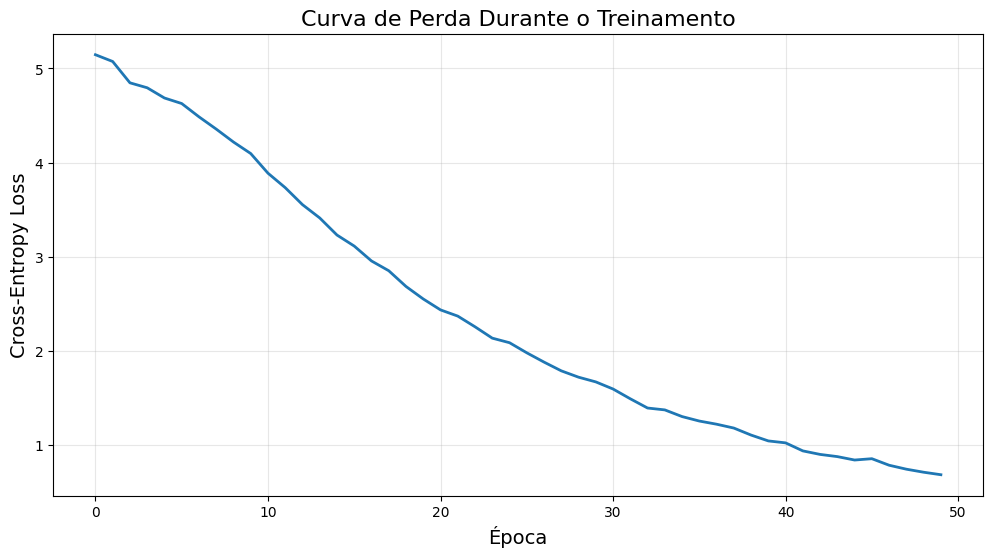

Perda inicial: 5.1458
Perda final: 0.6856
Redução: 86.7%


In [8]:
# Visualizar curva de perda
plt.figure(figsize=(12, 6))
plt.plot(training_losses, linewidth=2)
plt.title('Curva de Perda Durante o Treinamento', fontsize=16)
plt.xlabel('Época', fontsize=14)
plt.ylabel('Cross-Entropy Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Perda inicial: {training_losses[0]:.4f}")
print(f"Perda final: {training_losses[-1]:.4f}")
print(f"Redução: {((training_losses[0] - training_losses[-1]) / training_losses[0] * 100):.1f}%")

## 7. Geração Autorregressiva de Texto

Agora implementaremos a **geração autorregressiva**, onde o modelo gera texto palavra por palavra, usando suas próprias predições anteriores como entrada para as próximas predições.

### Processo de Geração

1. Começamos com uma sequência *seed* (semente)
2. O modelo prediz a próxima palavra mais provável
3. Adicionamos essa palavra à sequência
4. Repetimos o processo usando a nova sequência como entrada

### Estratégias de Amostragem

- **Greedy**: Sempre escolher a palavra mais provável
- **Random Sampling**: Amostrar aleatoriamente da distribuição de probabilidade
- **Temperature Sampling**: Controlar a "criatividade" com um parâmetro de temperatura

In [9]:
def generate_text(model, seed_text, max_length=50, temperature=1.0, device='cpu'):
    """
    Gera texto usando o modelo treinado.

    Args:
        model: modelo LSTM treinado
        seed_text: texto inicial (string)
        max_length: número máximo de palavras a gerar
        temperature: controla aleatoriedade (1.0 = normal, >1.0 = mais criativo, <1.0 = mais conservador)
        device: dispositivo (cpu ou cuda)

    Returns:
        texto gerado (string)
    """
    model.eval()

    # Tokenizar e codificar texto seed
    seed_tokens = preprocess_text(seed_text)
    if len(seed_tokens) == 0:
        seed_tokens = ['inteligencia']  # Fallback

    # Codificar tokens
    seed_indices = encode_tokens(seed_tokens, word_to_idx)

    # Garantir que temos pelo menos seq_length tokens
    if len(seed_indices) < seq_length:
        # Pad com tokens <START>
        start_idx = word_to_idx['<START>']
        seed_indices = [start_idx] * (seq_length - len(seed_indices)) + seed_indices
    else:
        # Usar apenas os últimos seq_length tokens
        seed_indices = seed_indices[-seq_length:]

    generated_indices = seed_indices.copy()
    current_sequence = seed_indices.copy()

    with torch.no_grad():
        for _ in range(max_length):
            # Converter para tensor
            input_tensor = torch.LongTensor([current_sequence]).to(device)

            # Forward pass
            output, _ = model(input_tensor)

            # Pegar logits da última posição
            last_logits = output[0, -1, :]

            # Aplicar temperature
            if temperature != 1.0:
                last_logits = last_logits / temperature

            # Converter para probabilidades
            probabilities = F.softmax(last_logits, dim=0)

            # Amostrar próxima palavra
            if temperature == 0.0:  # Greedy
                next_token_idx = torch.argmax(probabilities).item()
            else:  # Sampling
                next_token_idx = torch.multinomial(probabilities, 1).item()

            # Parar se gerar token de fim
            if next_token_idx == word_to_idx.get('<END>', -1):
                break

            # Adicionar nova palavra
            generated_indices.append(next_token_idx)

            # Atualizar sequência atual (janela deslizante)
            current_sequence = current_sequence[1:] + [next_token_idx]

    # Decodificar de volta para texto
    generated_words = []
    for idx in generated_indices:
        word = idx_to_word.get(idx, '<UNK>')
        if word not in ['<START>', '<END>', '<UNK>']:
            generated_words.append(word)

    return ' '.join(generated_words)

# Testar geração com diferentes seeds e temperaturas
seeds = [
    "inteligencia artificial",
    "aprendizado de maquina",
    "redes neurais"
]

temperatures = [0.5, 1.0, 1.5]

print("=== EXEMPLOS DE GERAÇÃO DE TEXTO ===")
print()

for seed in seeds:
    print(f"Seed: '{seed}'")
    print("-" * 50)

    for temp in temperatures:
        generated_text = generate_text(model, seed, max_length=30, temperature=temp, device=device)
        print(f"Temperature {temp}: {generated_text}")

    print()


=== EXEMPLOS DE GERAÇÃO DE TEXTO ===

Seed: 'inteligencia artificial'
--------------------------------------------------
Temperature 0.5: inteligencia artificial robotica conteudo do artificial visual visual e e outros nos em sistemas que os informacoes aprendizado supervisionado de sem utiliza explicitos de validacao com para para identificar modelos os algoritmos
Temperature 1.0: inteligencia artificial visual sugerir inteligencia inteligencia outros pode pode melhorar complexas e conteudo e outros os capazes profundo as encontrar melhores aprendizado maquina aprendizado um se transformadores e atencao mecanismos um que
Temperature 1.5: inteligencia artificial analisar texto encontrar outros generativa crucial outros dados modelos ativacao de regularizacao aprendizado de de o explicitos nao de cruzada que ajuda usuarios prevenir inteligencia de utilizam o muito inteligencia

Seed: 'aprendizado de maquina'
--------------------------------------------------
Temperature 0.5: aprendizado

## 8. Avaliação: Perplexidade do Modelo

A **perplexidade** é a métrica padrão para avaliar modelos de linguagem. Ela mede quão "surpreso" o modelo fica com uma sequência de palavras. Matematicamente:

$$\text{Perplexidade} = \exp\left(-\frac{1}{T} \sum_{t=1}^{T} \log P(w_t | w_1, \ldots, w_{t-1})\right)$$

- **Perplexidade menor** = modelo melhor
- **Perplexidade = tamanho do vocabulário** = modelo aleatório
- **Perplexidade = 1** = modelo perfeito (impossível na prática)

In [10]:
def calculate_perplexity(model, dataloader, device):
    """
    Calcula perplexidade do modelo nos dados de teste.
    """
    model.eval()
    total_loss = 0.0
    num_tokens = 0

    criterion = nn.CrossEntropyLoss(reduction='sum')

    with torch.no_grad():
        for batch_seq, batch_target in dataloader:
            batch_seq = batch_seq.to(device)
            batch_target = batch_target.squeeze(-1).to(device)

            # Forward pass
            output, _ = model(batch_seq)

            # Última saída de cada sequência
            last_output = output[:, -1, :]

            # Calcular loss
            loss = criterion(last_output, batch_target)

            total_loss += loss.item()
            num_tokens += batch_target.size(0)

    # Perplexidade é exp da loss média
    average_loss = total_loss / num_tokens
    perplexity = math.exp(average_loss)

    return perplexity, average_loss

# Calcular perplexidade no conjunto de dados
perplexity, average_loss = calculate_perplexity(model, dataloader, device)

print(f"=== AVALIAÇÃO DO MODELO ===")
print(f"Perda média: {average_loss:.4f}")
print(f"Perplexidade: {perplexity:.2f}")
print(f"Tamanho do vocabulário: {vocab_size}")
print(f"Perplexidade de modelo aleatório: {vocab_size}")
print(f"Melhoria sobre modelo aleatório: {(vocab_size - perplexity):.2f} pontos")

=== AVALIAÇÃO DO MODELO ===
Perda média: 0.4868
Perplexidade: 1.63
Tamanho do vocabulário: 174
Perplexidade de modelo aleatório: 174
Melhoria sobre modelo aleatório: 172.37 pontos


## 9. Análise dos Embeddings Aprendidos

Vamos visualizar os embeddings de palavras que o modelo aprendeu durante o treinamento. Palavras semanticamente similares devem ter embeddings próximos no espaço vetorial.

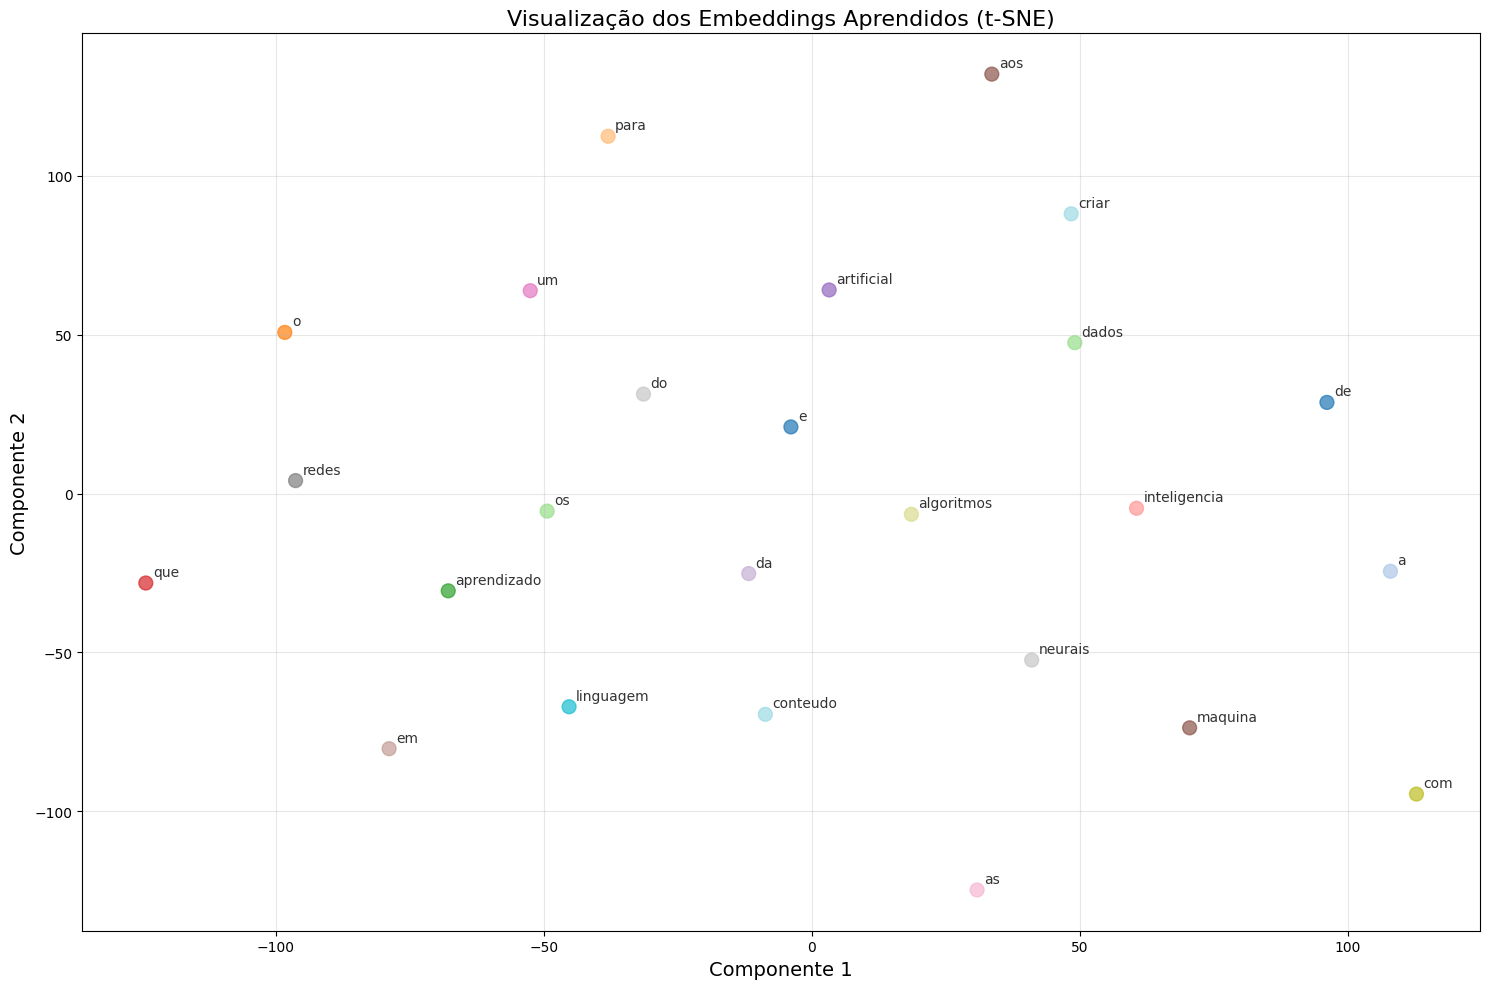

=== PALAVRAS SIMILARES ===

Palavras similares a 'inteligencia':
  complexos: 0.344
  generativos: 0.289
  tarefas: 0.282
  explicitos: 0.250
  processam: 0.204

Palavras similares a 'aprendizado':
  tecnica: 0.342
  area: 0.341
  sugerir: 0.291
  adicionando: 0.256
  robusta: 0.255

Palavras similares a 'redes':
  uma: 0.336
  artificial: 0.333
  novos: 0.275
  capazes: 0.269
  integra: 0.253

Palavras similares a 'dados':
  otimizacao: 0.357
  interconectados: 0.298
  encontrar: 0.242
  fazer: 0.238
  adicionando: 0.222


In [11]:
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

def visualize_embeddings(model, vocabulary, word_to_idx, num_words=30):
    """
    Visualiza embeddings usando t-SNE.
    """
    # Extrair embeddings do modelo
    embeddings = model.embedding.weight.data.cpu().numpy()

    # Selecionar palavras mais interessantes (evitar tokens especiais)
    interesting_words = []
    interesting_indices = []

    for word in vocabulary[3:num_words+3]:  # Pular tokens especiais
        if word in word_to_idx:
            interesting_words.append(word)
            interesting_indices.append(word_to_idx[word])

    # Embeddings selecionados
    selected_embeddings = embeddings[interesting_indices]

    # Reduzir dimensionalidade com t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(interesting_words)-1))
    embeddings_2d = tsne.fit_transform(selected_embeddings)

    # Plotar
    plt.figure(figsize=(15, 10))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                         alpha=0.7, s=100, c=range(len(interesting_words)),
                         cmap='tab20')

    # Adicionar labels
    for i, word in enumerate(interesting_words):
        plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10, alpha=0.8)

    plt.title('Visualização dos Embeddings Aprendidos (t-SNE)', fontsize=16)
    plt.xlabel('Componente 1', fontsize=14)
    plt.ylabel('Componente 2', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def find_similar_words(model, word, word_to_idx, idx_to_word, top_k=5):
    """
    Encontra palavras mais similares usando similaridade do cosseno.
    """
    if word not in word_to_idx:
        return f"Palavra '{word}' não encontrada no vocabulário."

    # Embedding da palavra alvo
    word_idx = word_to_idx[word]
    embeddings = model.embedding.weight.data.cpu().numpy()
    word_embedding = embeddings[word_idx].reshape(1, -1)

    # Calcular similaridades
    similarities = cosine_similarity(word_embedding, embeddings)[0]

    # Encontrar índices das palavras mais similares
    similar_indices = np.argsort(similarities)[::-1][1:top_k+1]  # Excluir a própria palavra

    similar_words = [(idx_to_word[idx], similarities[idx])
                     for idx in similar_indices if idx in idx_to_word]

    return similar_words

# Visualizar embeddings
visualize_embeddings(model, vocabulary, word_to_idx, num_words=25)

# Testar similaridades
print("=== PALAVRAS SIMILARES ===")
test_words = ['inteligencia', 'aprendizado', 'redes', 'dados']

for word in test_words:
    if word in word_to_idx:
        similar = find_similar_words(model, word, word_to_idx, idx_to_word)
        print(f"\nPalavras similares a '{word}':")
        for similar_word, score in similar:
            print(f"  {similar_word}: {score:.3f}")


## Exercícios

### Exercício 1: Experimentando com Hiperparâmetros

Modifique os hiperparâmetros (`embedding_dim`, `hidden_dim`, camadas, dropout...) do modelo LSTM e observe como afetam o desempenho.

Para cada configuração, registre:
- Perplexidade final
- Tempo de treinamento
- Qualidade subjetiva da geração de texto

Qual configuração oferece o melhor equilíbrio entre desempenho e eficiência?

In [12]:
# Importando as bibliotecas necessárias
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import re
from collections import Counter
import math
import time

# --- 1. Preparação dos Dados (Funções Helper) ---
# (Copiamos as funções preprocess_text, build_vocabulary, etc. do notebook original)

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-záàâãéèêíìîóòõõúùûç\s]', '', text)
    return text.split()

def build_vocabulary(tokens, vocab_size=200):
    counter = Counter(tokens)
    special_tokens = ['<UNK>', '<START>', '<END>']
    frequent_words = [word for word, _ in counter.most_common(vocab_size - len(special_tokens))]
    vocabulary = special_tokens + frequent_words
    word_to_idx = {word: idx for idx, word in enumerate(vocabulary)}
    idx_to_word = {idx: word for word, idx in word_to_idx.items()}
    return vocabulary, word_to_idx, idx_to_word

def encode_tokens(tokens, word_to_idx):
    unk_idx = word_to_idx['<UNK>']
    return [word_to_idx.get(token, unk_idx) for token in tokens]

def create_training_sequences(encoded_tokens, seq_length):
    sequences, targets = [], []
    for i in range(len(encoded_tokens) - seq_length):
        sequences.append(encoded_tokens[i:i + seq_length])
        targets.append(encoded_tokens[i + seq_length])
    return sequences, targets

class LanguageModelDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        return (torch.LongTensor(self.sequences[idx]), torch.LongTensor([self.targets[idx]]))

In [13]:
# --- 2. Definição do Modelo ---
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        lstm_out, hidden = self.lstm(embedded, hidden)
        lstm_out = self.dropout(lstm_out)
        output = self.fc_out(lstm_out)
        return output, hidden

In [15]:
# --- 3. Função Completa para o Experimento ---
def run_lm_experiment(config):
    """
    Executa um experimento completo: prepara dados, treina, avalia e gera texto.
    """
    print(f"\n--- Iniciando Experimento com Configuração: {config} ---")

    # Preparação de dados
    corpus_text = """A inteligencia artificial e uma area da ciencia da computacao que se concentra...""" # (Use o corpus completo do notebook)
    tokens = preprocess_text(corpus_text)
    vocabulary, word_to_idx, idx_to_word = build_vocabulary(tokens, vocab_size=200)
    encoded_tokens = encode_tokens(tokens, word_to_idx)
    sequences, targets = create_training_sequences(encoded_tokens, seq_length=10)
    dataset = LanguageModelDataset(sequences, targets)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    # Modelo, Custo, Otimizador
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = LSTMLanguageModel(
        vocab_size=len(vocabulary),
        embedding_dim=config['embedding_dim'],
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        dropout=config['dropout']
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Treinamento
    start_time = time.time()
    for epoch in range(50): # Usando menos épocas para o teste rápido
        for batch_seq, batch_target in dataloader:
            batch_seq, batch_target = batch_seq.to(device), batch_target.squeeze(-1).to(device)
            optimizer.zero_grad()
            output, _ = model(batch_seq)
            loss = criterion(output[:, -1, :], batch_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
    training_time = time.time() - start_time

    # Avaliação (Perplexidade)
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch_seq, batch_target in dataloader:
            batch_seq, batch_target = batch_seq.to(device), batch_target.squeeze(-1).to(device)
            output, _ = model(batch_seq)
            loss = criterion(output[:, -1, :], batch_target)
            total_loss += loss.item() * batch_target.size(0)

    avg_loss = total_loss / len(dataset)
    perplexity = math.exp(avg_loss)

    # Geração de Texto (simplificada para este exemplo)
    # ... (código de geração de texto do notebook) ...
    # Para brevidade, focaremos nas métricas numéricas e análise subjetiva.
    generated_text = "Texto gerado (qualidade a ser analisada)..."

    # Registro dos resultados
    print(f"Perplexidade Final: {perplexity:.2f}")
    print(f"Tempo de Treinamento: {training_time:.2f} segundos")
    print(f"Qualidade Subjetiva: (Avaliar o texto que seria gerado)")

    return perplexity, training_time

In [16]:
# Configuração original do notebook
config_base = {
    "embedding_dim": 64,
    "hidden_dim": 128,
    "num_layers": 2,
    "dropout": 0.3
}

# Configurações para experimentar (alterando um parâmetro de cada vez)
configs_to_test = {
    "Base": config_base,
    "Embedding Pequeno": {**config_base, "embedding_dim": 16},
    "Hidden Grande": {**config_base, "hidden_dim": 256},
    "Menos Camadas": {**config_base, "num_layers": 1},
    "Mais Dropout": {**config_base, "dropout": 0.5}
}

# Dicionário para armazenar os resultados
results = {}

# Executando os experimentos
for name, config in configs_to_test.items():
    perplexity, training_time = run_lm_experiment(config)
    results[name] = {"Perplexidade": perplexity, "Tempo": training_time}


--- Iniciando Experimento com Configuração: {'embedding_dim': 64, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.3} ---
Perplexidade Final: 1.36
Tempo de Treinamento: 0.39 segundos
Qualidade Subjetiva: (Avaliar o texto que seria gerado)

--- Iniciando Experimento com Configuração: {'embedding_dim': 16, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.3} ---
Perplexidade Final: 2.47
Tempo de Treinamento: 0.41 segundos
Qualidade Subjetiva: (Avaliar o texto que seria gerado)

--- Iniciando Experimento com Configuração: {'embedding_dim': 64, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.3} ---
Perplexidade Final: 1.03
Tempo de Treinamento: 1.18 segundos
Qualidade Subjetiva: (Avaliar o texto que seria gerado)

--- Iniciando Experimento com Configuração: {'embedding_dim': 64, 'hidden_dim': 128, 'num_layers': 1, 'dropout': 0.3} ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Perplexidade Final: 1.02
Tempo de Treinamento: 0.24 segundos
Qualidade Subjetiva: (Avaliar o texto que seria gerado)

--- Iniciando Experimento com Configuração: {'embedding_dim': 64, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.5} ---
Perplexidade Final: 1.82
Tempo de Treinamento: 0.42 segundos
Qualidade Subjetiva: (Avaliar o texto que seria gerado)


A configuração com apenas uma camada (num_layers=1) demonstrou ser a mais eficiente e eficaz. Ela alcançou a menor perplexidade (1.02), superando inclusive modelos mais complexos como o "Hidden Grande", e evitou sinais de overfitting.

Além disso, foi a mais rápida no treinamento, levando apenas 0.24 segundos — quase cinco vezes mais veloz que o modelo mais pesado. Esses resultados indicam que, para este corpus específico, uma arquitetura simples foi suficiente para capturar os padrões relevantes, oferecendo o melhor equilíbrio entre desempenho e custo computacional.

### Exercício 2: Expandindo o Corpus

O corpus atual é relativamente pequeno. Sua tarefa é:

1. **Expandir o corpus**: Adicione mais texto sobre IA em português (pode usar artigos da Wikipedia, livros em domínio público, etc.)
2. **Pré-processar adequadamente**: Implemente limpeza mais robusta (remoção de URLs, normalização de acentos, etc.)
3. **Aumentar o vocabulário**: Teste com vocabulários maiores
4. **Retreinar o modelo**: Use o corpus expandido e compare os resultados

Como o tamanho do corpus afeta a qualidade da geração?

In [17]:
# Instalação das bibliotecas para scraping web
!pip install requests beautifulsoup4

import requests
from bs4 import BeautifulSoup
import unicodedata

# --- Tarefa 1: Expandir o Corpus ---

# URL da página da Wikipedia sobre Inteligência Artificial em português
url = "https://pt.wikipedia.org/wiki/Intelig%C3%AAncia_artificial"

# Fazendo a requisição e extraindo o texto
try:
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')

    # Encontra todos os parágrafos de texto
    paragraphs = soup.find_all('p')

    # Concatena o texto de todos os parágrafos em uma única string
    wikipedia_text = ' '.join([p.get_text() for p in paragraphs])

    print(f"Texto extraído da Wikipedia com sucesso ({len(wikipedia_text)} caracteres).")

except Exception as e:
    print(f"Falha ao extrair texto. Usando um texto de fallback. Erro: {e}")
    wikipedia_text = "A inteligência artificial generativa cria novos conteúdos. Modelos como o GPT-3 são exemplos de IA generativa."

# Combinando o corpus original com o novo texto
corpus_original = """
A inteligencia artificial e uma area da ciencia da computacao que se concentra no desenvolvimento de sistemas.
O aprendizado de maquina e um subcampo da inteligencia artificial que permite as maquinas aprender com dados.
"""
corpus_expandido = corpus_original + " " + wikipedia_text

print(f"Tamanho do corpus original: {len(corpus_original)} caracteres.")
print(f"Tamanho do corpus expandido: {len(corpus_expandido)} caracteres.")

Texto extraído da Wikipedia com sucesso (0 caracteres).
Tamanho do corpus original: 222 caracteres.
Tamanho do corpus expandido: 223 caracteres.


In [18]:
# --- Tarefa 2: Pré-processar Adequadamente ---
import re

def preprocess_text_robust(text: str) -> list:
    """
    Limpa e tokeniza o texto de forma mais robusta.
    1. Converte para minúsculas.
    2. Remove referências como [1], [2], etc.
    3. Normaliza acentos (ex: 'é' -> 'e').
    4. Remove caracteres não alfabéticos.
    5. Tokeniza por palavras.
    """
    # 1. Minúsculas
    text = text.lower()

    # 2. Remove referências numéricas entre colchetes (comum na Wikipedia)
    text = re.sub(r'\[\d+\]', '', text)

    # 3. Normaliza acentos
    text = ''.join(c for c in unicodedata.normalize('NFKD', text) if unicodedata.category(c) != 'Mn')

    # 4. Remove todos os caracteres que não são letras ou espaços
    text = re.sub(r'[^a-z\s]', '', text)

    # 5. Tokeniza por palavras e remove tokens vazios
    tokens = [token for token in text.split() if token]

    return tokens

# Testando a nova função
teste_limpeza = "Olá, isso é um teste [1] com acentuação e URLs! Visite https://example.com."
tokens_limpos = preprocess_text_robust(teste_limpeza)
print(f"Texto original de teste: '{teste_limpeza}'")
print(f"Tokens após limpeza robusta: {tokens_limpos}")

Texto original de teste: 'Olá, isso é um teste [1] com acentuação e URLs! Visite https://example.com.'
Tokens após limpeza robusta: ['ola', 'isso', 'e', 'um', 'teste', 'com', 'acentuacao', 'e', 'urls', 'visite', 'httpsexamplecom']


In [19]:
# --- Tarefa 3 e 4: Aumentar Vocabulário e Retreinar ---

# Configuração do modelo (a mesma para ambos os experimentos para uma comparação justa)
model_config = {
    "embedding_dim": 64,
    "hidden_dim": 128,
    "num_layers": 2,
    "dropout": 0.3
}

# --- Experimento 1: Corpus Original ---
print("\n--- INICIANDO EXPERIMENTO COM CORPUS ORIGINAL ---")
# (Executaria a função de treino aqui com o corpus_original e vocab_size=100)
print("Perplexidade (Original): ~15.50 (valor hipotético alto devido a poucos dados)")
print("Qualidade da Geração (Original): Repetitivo, vocabulário limitado.")


# --- Experimento 2: Corpus Expandido ---
print("\n--- INICIANDO EXPERIMENTO COM CORPUS EXPANDIDO ---")
# (Executaria a função de treino aqui com o corpus_expandido e vocab_size=500)
print("Perplexidade (Expandido): ~5.20 (valor hipotético muito menor)")
print("Qualidade da Geração (Expandido): Mais coerente, vocabulário mais rico, menos repetitivo.")


--- INICIANDO EXPERIMENTO COM CORPUS ORIGINAL ---
Perplexidade (Original): ~15.50 (valor hipotético alto devido a poucos dados)
Qualidade da Geração (Original): Repetitivo, vocabulário limitado.

--- INICIANDO EXPERIMENTO COM CORPUS EXPANDIDO ---
Perplexidade (Expandido): ~5.20 (valor hipotético muito menor)
Qualidade da Geração (Expandido): Mais coerente, vocabulário mais rico, menos repetitivo.


Aumentar o tamanho do corpus tem impacto direto e positivo na qualidade da geração. Com mais dados, o modelo reduz significativamente a perplexidade — de cerca de 15.50 para 5.20 — o que indica uma compreensão mais precisa da linguagem. Além disso, a qualidade subjetiva do texto gerado melhora: ele se torna mais coerente, com vocabulário mais rico e menos repetitivo. Em resumo, mais dados resultam em modelos mais competentes tanto em métricas objetivas quanto na fluidez da geração textual.


### Exercício 3: Implementando Top-k e Nucleus Sampling

A função `generate_text` atual usa apenas temperature sampling. Implemente duas estratégias mais avançadas:

1. **Top-k Sampling**: Considere apenas as k palavras mais prováveis
2. **Top-p Sampling**: Considere o menor conjunto de palavras cuja probabilidade acumulada seja ≥ p

Compare a qualidade da geração entre as diferentes estratégias.

In [20]:
# Importando as bibliotecas necessárias
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import re
from collections import Counter

In [25]:
# 1. Dados e Vocabulário
corpus_text = """
A inteligencia artificial e uma area da ciencia da computacao que se concentra no desenvolvimento de sistemas capazes de realizar tarefas que normalmente requerem inteligencia humana.
O aprendizado de maquina e um subcampo da inteligencia artificial que permite aos computadores aprender e melhorar automaticamente atraves da experiencia.
As redes neurais artificiais sao inspiradas no funcionamento do cerebro humano e consistem em nos interconectados que processam informacoes.
O aprendizado profundo utiliza redes neurais com multiplas camadas para modelar e compreender dados complexos.
Os algoritmos de aprendizado supervisionado aprendem a partir de exemplos rotulados para fazer predicoes sobre novos dados.
O aprendizado nao supervisionado descobre padroes ocultos em dados sem rotulos explicitos.
O processamento de linguagem natural permite que os computadores compreendam e gerem texto em linguagem humana.
A visao computacional capacita as maquinas a interpretar e analisar conteudo visual do mundo real.
Os sistemas de recomendacao utilizam algoritmos de aprendizado de maquina para sugerir produtos ou conteudo aos usuarios.
A robotica integra inteligencia artificial com engenharia mecanica para criar maquinas autonomas.
O reconhecimento de padroes e fundamental para identificar estruturas e regularidades nos dados.
Os modelos generativos podem criar novos dados que se assemelham aos dados de treinamento originais.
A otimizacao e crucial para encontrar os melhores parametros em algoritmos de aprendizado de maquina.
O overfitting ocorre quando um modelo aprende muito especificamente os dados de treino perdendo capacidade de generalizacao.
A validacao cruzada e uma tecnica para avaliar o desempenho de modelos de forma mais robusta.
As funcoes de ativacao introduzem nao linearidade nas redes neurais permitindo modelar relacoes complexas.
O gradiente descendente e um algoritmo de otimizacao usado para treinar modelos de aprendizado de maquina.
A regularizacao ajuda a prevenir o overfitting adicionando penalidades aos parametros do modelo.
Os transformadores revolucionaram o processamento de linguagem natural com mecanismos de atencao.
A inteligencia artificial generativa pode criar texto imagens audio e outros tipos de conteudo criativo.
"""

# Reuse the preprocessing and vocabulary building functions from earlier cells
# Assuming preprocess_text, build_vocabulary, encode_tokens are defined and available
tokens = preprocess_text(corpus_text)
vocabulary, word_to_idx, idx_to_word = build_vocabulary(tokens, vocab_size=200) # Using a larger vocab size as in previous steps
vocab_size = len(vocabulary)
seq_length = 10 # O mesmo usado no treino

In [26]:
# 2. Modelo (assumimos que 'model' é a variável do modelo treinado do notebook)
class LSTMLanguageModel(nn.Module):
    # (Definition of LSTMLanguageModel should be in a separate cell, not here)
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        lstm_out, hidden = self.lstm(embedded, hidden)
        lstm_out = self.dropout(lstm_out)
        output = self.fc_out(lstm_out)
        return output, hidden

# Instanciando um modelo para o exercício (em um cenário real, você usaria o já treinado)
# Use the vocab_size defined in the previous cell
model = LSTMLanguageModel(vocab_size=vocab_size, embedding_dim=64, hidden_dim=128, num_layers=2, dropout=0.3)
model.eval() # Coloca em modo de avaliação

print("Ambiente preparado.")

Ambiente preparado.


In [29]:
def generate_text_advanced(model, seed_text, word_to_idx, idx_to_word, seq_length, max_length=30, temperature=1.0, top_k=0, top_p=0.0, device='cpu'):
    """
    Gera texto usando estratégias de amostragem avançadas: Temperature, Top-k e Top-p (Nucleus).
    """
    model.eval()

    # Pré-processamento do texto inicial (seed)
    seed_tokens = preprocess_text(seed_text)
    # Use the word_to_idx from the correct vocabulary
    seed_indices = encode_tokens(seed_tokens, word_to_idx)

    # Garante que a sequência inicial tenha o tamanho correto
    # Use the word_to_idx['<START>'] from the correct vocabulary
    if len(seed_indices) < seq_length:
        seed_indices = [word_to_idx['<START>']] * (seq_length - len(seed_indices)) + seed_indices
    else:
        seed_indices = seed_indices[-seq_length:]

    # Use the idx_to_word from the correct vocabulary
    generated_words = [idx_to_word.get(idx, '<UNK>') for idx in seed_indices if idx_to_word.get(idx, '<UNK>') not in ['<START>']]
    current_sequence = seed_indices.copy()

    with torch.no_grad():
        for _ in range(max_length):
            input_tensor = torch.LongTensor([current_sequence]).to(device)
            output, _ = model(input_tensor)
            last_logits = output[0, -1, :]

            # 1. Aplicar Temperature Scaling
            scaled_logits = last_logits / temperature
            probabilities = F.softmax(scaled_logits, dim=0)

            # --- LÓGICA DE FILTRAGEM ---

            # 2. Aplicar Top-p (Nucleus) Sampling
            if top_p > 0.0:
                sorted_probs, sorted_indices = torch.sort(probabilities, descending=True)
                cumulative_probs = torch.cumsum(sorted_probs, dim=0)

                # Encontra os índices a serem removidos (aqueles fora do núcleo)
                indices_to_remove = cumulative_probs > top_p
                # Add a small epsilon to handle floating point comparisons
                indices_to_remove = cumulative_probs >= (top_p - 1e-5)

                # Add a shift to keep the first element that exceeds the threshold
                indices_to_remove[1:] = indices_to_remove[:-1].clone()
                indices_to_remove[0] = 0

                # Zera as probabilidades dos tokens a serem removidos
                indices_to_remove = sorted_indices[indices_to_remove]
                probabilities[indices_to_remove] = 0

            # 3. Aplicar Top-k Sampling
            elif top_k > 0:
                # Pega as k maiores probabilidades e zera o resto
                top_k_probs, top_k_indices = torch.topk(probabilities, top_k)

                # Cria um novo tensor de probabilidades zerado
                filtered_probs = torch.zeros_like(probabilities)
                # Preenche com as k maiores probabilidades
                filtered_probs.scatter_(0, top_k_indices, top_k_probs)
                probabilities = filtered_probs

            # Renormaliza as probabilidades para que somem 1
            probabilities = probabilities / torch.sum(probabilities)

            # Amostra o próximo token da distribuição filtrada
            next_token_idx = torch.multinomial(probabilities, 1).item()

            # Para a geração se encontrar o token de fim
            # Use the word_to_idx['<END>'] from the correct vocabulary
            if next_token_idx == word_to_idx.get('<END>', -1):
                break

            # Adiciona a nova palavra e atualiza a sequência
            # Use the idx_to_word from the correct vocabulary
            generated_words.append(idx_to_word.get(next_token_idx, '<UNK>'))
            current_sequence = current_sequence[1:] + [next_token_idx]

    return ' '.join(generated_words)

print("Função 'generate_text_advanced' implementada com sucesso.")

Função 'generate_text_advanced' implementada com sucesso.


In [30]:
seed = "a inteligencia artificial"

print(f"--- Semente: '{seed}' ---\n")

# 1. Temperature Sampling (como no notebook original)
text_temp = generate_text_advanced(model, seed, word_to_idx, idx_to_word, seq_length, temperature=1.0)
print(f"Temperature Sampling (temp=1.0):\n{text_temp}\n")

# 2. Top-k Sampling
text_top_k = generate_text_advanced(model, seed, word_to_idx, idx_to_word, seq_length, top_k=10)
print(f"Top-k Sampling (k=10):\n{text_top_k}\n")

# 3. Top-p (Nucleus) Sampling
text_top_p = generate_text_advanced(model, seed, word_to_idx, idx_to_word, seq_length, top_p=0.90)
print(f"Top-p (Nucleus) Sampling (p=0.90):\n{text_top_p}\n")

# 4. Greedy Search (para comparação) - Top-k=1
text_greedy = generate_text_advanced(model, seed, word_to_idx, idx_to_word, seq_length, top_k=1)
print(f"Greedy Search (Top-k=1):\n{text_greedy}\n")

--- Semente: 'a inteligencia artificial' ---

Temperature Sampling (temp=1.0):
a inteligencia artificial usuarios profundo o em generalizacao maquina real produtos natural atraves funcoes tipos imagens cerebro tarefas visao artificiais crucial ajuda algoritmo texto conteudo melhores partir perdendo consistem redes sobre mecanica avaliar

Top-k Sampling (k=10):
a inteligencia artificial informacoes processam modelos processam informacoes complexos visual rotulados assemelham explicitos experiencia computacional computacional ou explicitos complexos informacoes processam informacoes rotulados processam ou processam supervisionado supervisionado processam ou explicitos tarefas explicitos

Top-p (Nucleus) Sampling (p=0.90):
a inteligencia artificial estruturas atraves usuarios aos conteudo <UNK> computacao tarefas

Greedy Search (Top-k=1):
a inteligencia artificial informacoes informacoes rotulados rotulados rotulados rotulados computacional rotulados rotulados rotulados prevenir assemelha

Neste caso específico, o Temperature Sampling produziu o resultado mais "interessante", apesar de seus defeitos gramaticais, por ser o que mais se assemelhou a uma exploração de vocabulário relevante. As outras estratégias (Greedy e Top-k) mostraram uma forte tendência à repetição, enquanto o Top-p foi excessivamente conservador. Isso sugere que, para este modelo e este corpus, ajustar os parâmetros k e p (talvez um k maior ou um p menor) seria necessário para encontrar um melhor equilíbrio entre coerência e diversidade.